# Retail Sales Exploratory Data Analysis

## Project Objective

This analysis evaluates sales, profitability, customer behavior, product performance, geographic trends, and seasonality within the retail dataset. The goal is to identify meaningful business patterns and develop actionable insights that can support management decision-making.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/sample_superstore_clean.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Discount Group
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Below 30%
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Below 30%
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Below 30%
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,30% or Higher
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Below 30%


In [3]:
print("Dataset dimensions:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset dimensions: (9994, 22)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Discount Group']


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [5]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

## 1. Executive Performance Overview

The analysis begins with a high-level assessment of revenue, profit, profitability, orders, customers, and transaction volume.

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
unique_orders = df["Order ID"].nunique()
unique_customers = df["Customer ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Unique Orders: {unique_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Transaction Lines: {len(df):,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Unique Orders: 5,009
Unique Customers: 793
Transaction Lines: 9,994


## 2. Annual Performance Analysis

Annual sales, profit, order volume, and profit margin are evaluated to identify changes in business performance over time.

In [7]:
annual_performance = (
    df.groupby("Order Year")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .round(2)
)

annual_performance["Profit_Margin_%"] = (
    annual_performance["Total_Profit"]
    / annual_performance["Total_Sales"] * 100
).round(2)

annual_performance

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
Order Year,,,,
2018,484247.50,49543.97,969,10.23
2019,470532.51,61618.60,1038,13.10
2020,609205.60,81795.17,1315,13.43
2021,733215.26,93439.27,1687,12.74


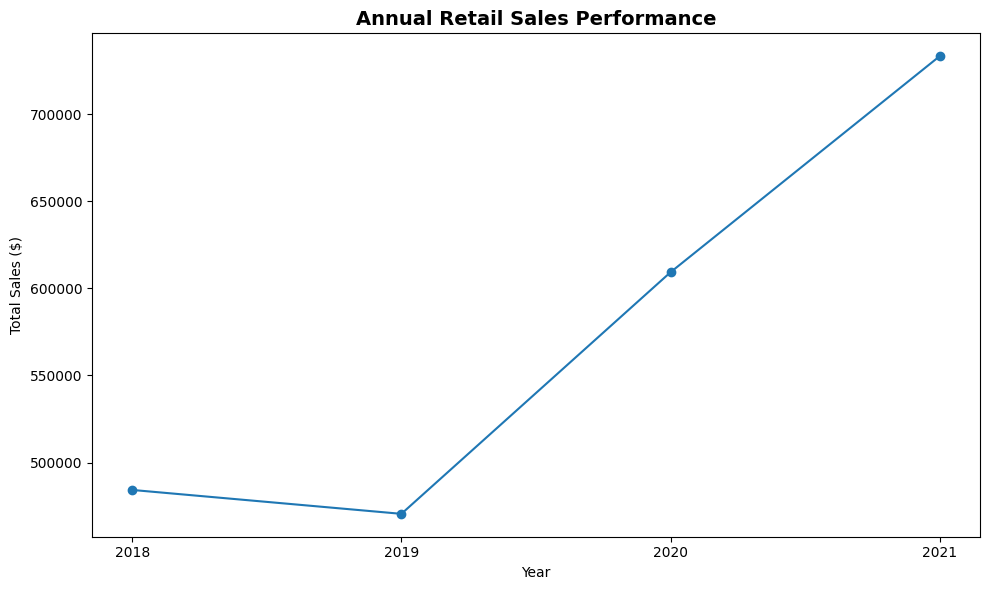

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    annual_performance.index,
    annual_performance["Total_Sales"],
    marker="o"
)

plt.title(
    "Annual Retail Sales Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(annual_performance.index)

plt.tight_layout()
plt.show()

### Year-over-Year Growth Analysis

Year-over-year growth rates are calculated to evaluate changes in sales, profit, and order volume. Comparing revenue growth with profitability growth helps determine whether business expansion is translating into proportional financial returns.

In [9]:
annual_performance["Sales_Growth_%"] = (
    annual_performance["Total_Sales"].pct_change() * 100
).round(2)

annual_performance["Profit_Growth_%"] = (
    annual_performance["Total_Profit"].pct_change() * 100
).round(2)

annual_performance["Order_Growth_%"] = (
    annual_performance["Orders"].pct_change() * 100
).round(2)

annual_performance

,Total_Sales,Total_Profit,Orders,Profit_Margin_%,Sales_Growth_%,Profit_Growth_%,Order_Growth_%
Order Year,,,,,,,
2018,484247.50,49543.97,969,10.23,NaN,NaN,NaN
2019,470532.51,61618.60,1038,13.10,-2.83,24.37,7.12
2020,609205.60,81795.17,1315,13.43,29.47,32.74,26.69
2021,733215.26,93439.27,1687,12.74,20.36,14.24,28.29


In [10]:
sales_growth_total = (
    annual_performance.loc[2021, "Total_Sales"] /
    annual_performance.loc[2018, "Total_Sales"] - 1
) * 100

profit_growth_total = (
    annual_performance.loc[2021, "Total_Profit"] /
    annual_performance.loc[2018, "Total_Profit"] - 1
) * 100

order_growth_total = (
    annual_performance.loc[2021, "Orders"] /
    annual_performance.loc[2018, "Orders"] - 1
) * 100

print(f"2018–2021 Sales Growth: {sales_growth_total:.2f}%")
print(f"2018–2021 Profit Growth: {profit_growth_total:.2f}%")
print(f"2018–2021 Order Growth: {order_growth_total:.2f}%")

2018–2021 Sales Growth: 51.41%
2018–2021 Profit Growth: 88.60%
2018–2021 Order Growth: 74.10%


## 3. Monthly Sales and Seasonality

Monthly performance is evaluated to identify recurring demand patterns, peak sales periods, and potential seasonality that may support inventory, staffing, marketing, and forecasting decisions.

In [11]:
monthly_performance = (
    df.groupby(["Order Month", "Order Month Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
    .sort_values("Order Month")
)

monthly_performance["Profit_Margin_%"] = (
    monthly_performance["Total_Profit"] /
    monthly_performance["Total_Sales"] * 100
).round(2)

monthly_performance.round(2)

,Order Month,Order Month Name,Total_Sales,Total_Profit,Orders,Profit_Margin_%
0,1,January,94924.84,9134.45,178,9.62
1,2,February,59751.25,10294.61,162,17.23
2,3,March,205005.49,28594.69,354,13.95
3,4,April,137762.13,11587.44,343,8.41
4,5,May,155028.81,22411.31,369,14.46
5,6,June,152718.68,21285.80,364,13.94
6,7,July,147238.10,13832.66,338,9.39
7,8,August,159044.06,21776.94,341,13.69
8,9,September,307649.95,36857.48,688,11.98
9,10,October,200322.98,31784.04,417,15.87


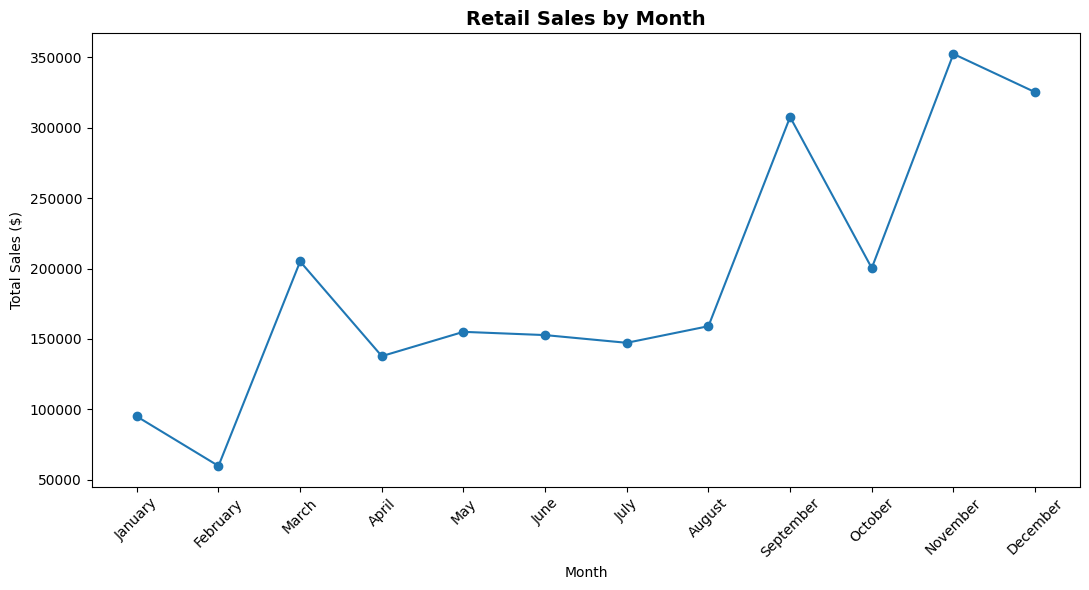

In [12]:
plt.figure(figsize=(11, 6))

plt.plot(
    monthly_performance["Order Month Name"],
    monthly_performance["Total_Sales"],
    marker="o"
)

plt.title(
    "Retail Sales by Month",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Annual Performance Interpretation

The business demonstrated substantial overall growth between 2018 and 2021. Total sales increased by 51.41%, while total profit increased by 88.60% and order volume increased by 74.10%.

Performance varied across individual years. In 2019, sales declined by 2.83%, yet profit increased by 24.37%, indicating improved profitability despite lower revenue. Strong expansion followed in 2020, with sales increasing 29.47% and profit increasing 32.74%.

Growth continued in 2021, when sales increased 20.36% and order volume increased 28.29%. However, profit increased by only 14.24%, while profit margin declined from 13.43% to 12.74%. This suggests that although the business continued expanding, profitability did not increase at the same rate as revenue during the most recent year.

### Seasonality Interpretation

The monthly analysis indicates substantial seasonality in retail demand. Sales are particularly strong during September, November, and December, with November generating the highest cumulative sales across the observation period.

However, higher sales volume does not consistently translate into stronger profitability. November generated approximately $352,461 in sales but achieved a profit margin of only 10.06%. In comparison, October generated approximately $200,323 in sales while producing a substantially stronger 15.87% profit margin.

February represents the lowest-sales month but achieved the highest monthly profit margin at 17.23%. These results demonstrate the importance of evaluating revenue and profitability together rather than using sales volume alone as an indicator of business performance.

In [13]:
year_month_sales = (
    df.groupby(["Order Year", "Order Month"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
)

year_month_sales.head()

,Order Year,Order Month,Total_Sales,Total_Profit
0,2018,1,14236.895,2450.1907
1,2018,2,4519.892,862.3084
2,2018,3,55691.009,498.7299
3,2018,4,28295.345,3488.8352
4,2018,5,23648.287,2738.7096


In [14]:
monthly_sales_pivot = year_month_sales.pivot(
    index="Order Month",
    columns="Order Year",
    values="Total_Sales"
)

monthly_sales_pivot.index = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

monthly_sales_pivot.round(2)

Order Year,2018,2019,2020,2021
Jan,14236.90,18174.08,18542.49,43971.37
Feb,4519.89,11951.41,22978.82,20301.13
Mar,55691.01,38726.25,51715.88,58872.35
Apr,28295.34,34195.21,38750.04,36521.54
May,23648.29,30131.69,56987.73,44261.11
Jun,34595.13,24797.29,40344.53,52981.73
Jul,33946.39,28765.32,39261.96,45264.42
Aug,27909.47,36898.33,31115.37,63120.89
Sep,81777.35,64595.92,73410.02,87866.65
Oct,31453.39,31404.92,59687.74,77776.92


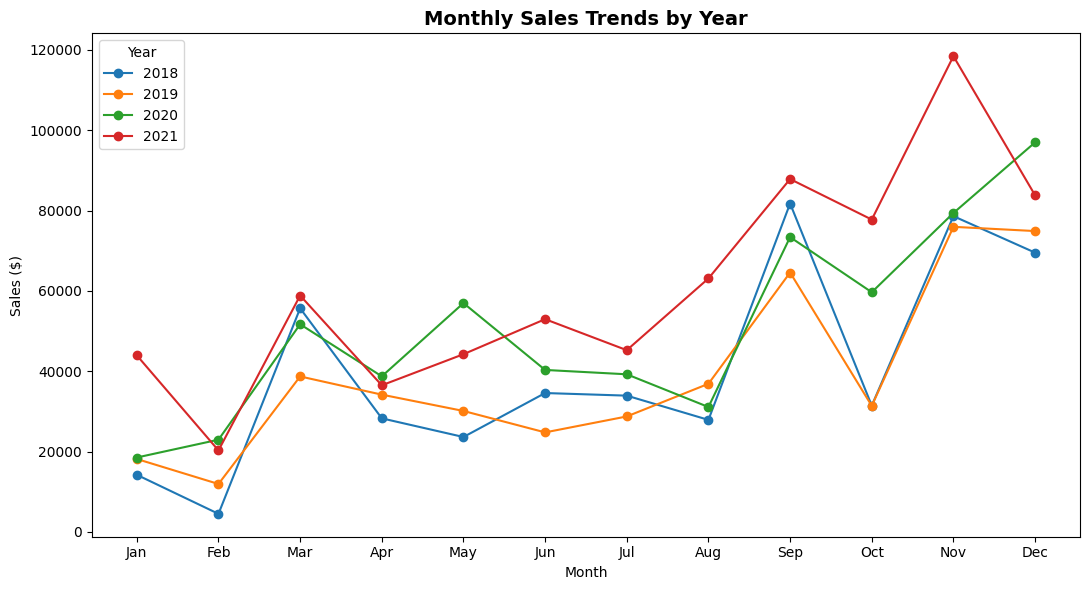

In [15]:
plt.figure(figsize=(11, 6))

for year in monthly_sales_pivot.columns:
    plt.plot(
        monthly_sales_pivot.index,
        monthly_sales_pivot[year],
        marker="o",
        label=str(year)
    )

plt.title(
    "Monthly Sales Trends by Year",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.legend(title="Year")

plt.tight_layout()
plt.show()

## 4. Product Category Performance

Sales and profitability are evaluated across product categories and sub-categories to identify the areas generating the greatest revenue, profit, and financial risk.

In [16]:
category_performance = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .round(2)
)

category_performance["Profit_Margin_%"] = (
    category_performance["Total_Profit"] /
    category_performance["Total_Sales"] * 100
).round(2)

category_performance.sort_values(
    "Total_Profit",
    ascending=False
)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
Category,,,,
Technology,836154.03,145454.95,1544,17.40
Office Supplies,719047.03,122490.80,3742,17.04
Furniture,741999.80,18451.27,1764,2.49


In [17]:
subcategory_performance = (
    df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .round(2)
)

subcategory_performance["Profit_Margin_%"] = (
    subcategory_performance["Total_Profit"] /
    subcategory_performance["Total_Sales"] * 100
).round(2)

subcategory_performance.sort_values(
    "Total_Profit",
    ascending=False
)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
Sub-Category,,,,
Copiers,149528.03,55617.82,68,37.20
Phones,330007.05,44515.73,814,13.49
Accessories,167380.32,41936.64,718,25.05
Paper,78479.21,34053.57,1191,43.39
Binders,203412.73,30221.76,1316,14.86
Chairs,328449.10,26590.17,576,8.10
Storage,223843.61,21278.83,777,9.51
Appliances,107532.16,18138.01,451,16.87
Furnishings,91705.16,13059.14,877,14.24


### Seasonal Trend Interpretation

The year-by-year monthly analysis provides additional evidence of recurring seasonality. Sales generally strengthen during the later months of the year, with September through December producing several of the highest monthly sales levels across the observation period.

Although the magnitude and timing of individual peaks vary by year, the recurring late-year increase suggests that demand is not evenly distributed throughout the calendar. This pattern may have implications for inventory planning, staffing, marketing activity, and sales forecasting.

The analysis also shows substantial growth in 2021, with monthly sales frequently exceeding corresponding periods in previous years.

### Category Performance Interpretation

Technology represents the strongest overall product category, generating approximately $836,154 in sales and $145,455 in profit with a 17.40% profit margin. Office Supplies also demonstrates strong profitability, producing a 17.04% margin.

Furniture presents a substantially different performance profile. Despite generating approximately $742,000 in sales, the category produced only $18,451 in profit, resulting in a 2.49% margin.

The large disparity between Furniture revenue and profitability suggests that sales volume alone does not adequately represent category performance. Additional sub-category analysis is necessary to identify the specific products responsible for margin deterioration.

## 5. Discount Impact by Product Sub-Category

Previous analysis identified substantial profitability differences across product groups. Discount behavior is therefore evaluated within individual sub-categories to determine whether aggressive discounting may contribute to poor financial performance.

In [18]:
subcategory_discount = (
    df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean"),
        Median_Discount=("Discount", "median"),
        Transactions=("Profit", "count")
    )
    .round(3)
)

subcategory_discount["Profit_Margin_%"] = (
    subcategory_discount["Total_Profit"] /
    subcategory_discount["Total_Sales"] * 100
).round(2)

subcategory_discount.sort_values("Profit_Margin_%")

,Total_Sales,Total_Profit,Average_Discount,Median_Discount,Transactions,Profit_Margin_%
Sub-Category,,,,,,
Tables,206965.532,-17725.481,0.261,0.3,319,-8.56
Bookcases,114879.996,-3472.556,0.211,0.2,228,-3.02
Supplies,46673.538,-1189.100,0.077,0.0,190,-2.55
Machines,189238.631,3384.757,0.306,0.2,115,1.79
Chairs,328449.103,26590.166,0.170,0.2,617,8.10
Storage,223843.608,21278.826,0.075,0.0,846,9.51
Phones,330007.054,44515.731,0.155,0.2,889,13.49
Furnishings,91705.164,13059.144,0.138,0.0,957,14.24
Binders,203412.733,30221.763,0.372,0.2,1523,14.86


In [19]:
furniture_analysis = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean"),
        Transactions=("Profit", "count")
    )
    .round(2)
)

furniture_analysis["Profit_Margin_%"] = (
    furniture_analysis["Total_Profit"] /
    furniture_analysis["Total_Sales"] * 100
).round(2)

furniture_analysis.sort_values("Total_Profit")

,Total_Sales,Total_Profit,Average_Discount,Transactions,Profit_Margin_%
Sub-Category,,,,,
Tables,206965.53,-17725.48,0.26,319,-8.56
Bookcases,114880.00,-3472.56,0.21,228,-3.02
Furnishings,91705.16,13059.14,0.14,957,14.24
Chairs,328449.10,26590.17,0.17,617,8.10


## 6. Customer Segment Performance

Customer segments are evaluated to determine which groups contribute the greatest sales and profit and whether meaningful differences exist in profitability across customer types.

In [20]:
segment_performance = (
    df.groupby("Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .round(2)
)

segment_performance["Profit_Margin_%"] = (
    segment_performance["Total_Profit"] /
    segment_performance["Total_Sales"] * 100
).round(2)

segment_performance.sort_values(
    "Total_Profit",
    ascending=False
)

,Total_Sales,Total_Profit,Orders,Customers,Profit_Margin_%
Segment,,,,,
Consumer,1161401.34,134119.21,2586,409,11.55
Corporate,706146.37,91979.13,1514,236,13.03
Home Office,429653.15,60298.68,909,148,14.03


### Product and Customer Performance Interpretation

Profitability varies substantially across product sub-categories. Tables generated approximately $206,966 in sales but produced a $17,725 loss, resulting in a -8.56% profit margin. Bookcases were also unprofitable, while Machines generated nearly $189,239 in sales but achieved only a 1.79% margin.

Discount behavior appears related to several of these results. Tables received an average discount of approximately 26%, while Machines averaged approximately 31%. However, discounting alone does not explain profitability. Binders maintained a positive 14.86% overall margin despite relatively high average discounting, demonstrating that product characteristics and discount structure should be considered together.

At the customer level, the Consumer segment generated the greatest sales and total profit but produced the lowest margin at 11.55%. Home Office generated substantially lower sales volume but achieved the strongest segment margin at 14.03%. These findings demonstrate that the largest revenue-producing segments are not necessarily the most efficient from a profitability perspective.

## 7. Geographic Performance Analysis

Regional and state-level performance is evaluated to identify geographic differences in sales, profitability, and margin. This analysis helps determine whether financial performance is broadly distributed or concentrated within specific markets.

In [21]:
regional_performance = (
    df.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .round(2)
)

regional_performance["Profit_Margin_%"] = (
    regional_performance["Total_Profit"] /
    regional_performance["Total_Sales"] * 100
).round(2)

regional_performance.sort_values(
    "Total_Profit",
    ascending=False
)

,Total_Sales,Total_Profit,Orders,Customers,Profit_Margin_%
Region,,,,,
West,725457.82,108418.45,1611,686,14.94
East,678781.24,91522.78,1401,674,13.48
South,391721.90,46749.43,822,512,11.93
Central,501239.89,39706.36,1175,629,7.92


In [22]:
state_performance = (
    df.groupby("State")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .round(2)
)

state_performance["Profit_Margin_%"] = (
    state_performance["Total_Profit"] /
    state_performance["Total_Sales"] * 100
).round(2)

state_performance.sort_values(
    "Total_Profit"
).head(10)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
State,,,,
Texas,170188.05,-25729.36,487,-15.12
Ohio,78258.14,-16971.38,236,-21.69
Pennsylvania,116511.91,-15559.96,288,-13.35
Illinois,80166.10,-12607.89,276,-15.73
North Carolina,55603.16,-7490.91,136,-13.47
Colorado,32108.12,-6527.86,79,-20.33
Tennessee,30661.87,-5341.69,91,-17.42
Arizona,35282.00,-3427.92,108,-9.72
Florida,89473.71,-3399.30,200,-3.80


In [23]:
state_performance.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
State,,,,
California,457687.63,76381.39,1021,16.69
New York,310876.27,74038.55,562,23.82
Washington,138641.27,33402.65,256,24.09
Michigan,76269.61,24463.19,117,32.07
Virginia,70636.72,18597.95,115,26.33
Indiana,53555.36,18382.94,73,34.33
Georgia,49095.84,16250.04,91,33.10
Kentucky,36591.75,11199.70,61,30.61
Minnesota,29863.15,10823.19,44,36.24


In [24]:
texas_analysis = df[df["State"] == "Texas"].agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
})

texas_margin = (
    texas_analysis["Profit"] /
    texas_analysis["Sales"] * 100
)

print(f"Texas Sales: ${texas_analysis['Sales']:,.2f}")
print(f"Texas Profit: ${texas_analysis['Profit']:,.2f}")
print(f"Texas Profit Margin: {texas_margin:.2f}%")
print(f"Texas Average Discount: {texas_analysis['Discount']:.2%}")

Texas Sales: $170,188.05
Texas Profit: $-25,729.36
Texas Profit Margin: -15.12%
Texas Average Discount: 37.02%


### Geographic Performance Interpretation

Geographic performance varies substantially across the business. The West represents the strongest region, generating approximately $108,418 in profit with a 14.94% profit margin. The East also demonstrates strong performance with a 13.48% margin. In contrast, the Central region produces the lowest regional margin at 7.92%.

State-level analysis reveals several significant profitability concerns. Texas generated approximately $170,188 in sales but produced a $25,729 loss, resulting in a -15.12% profit margin. Texas transactions also received an average discount of approximately 37%, providing additional evidence that aggressive discounting may be associated with profitability erosion in this market.

Ohio, Pennsylvania, Illinois, North Carolina, Colorado, Tennessee, Arizona, Florida, and Oregon also generated negative overall profit. These results indicate that profitability challenges are geographically concentrated and warrant further investigation into regional pricing, discounting, product mix, and customer behavior.

## 8. Customer Performance and Revenue Concentration

Customer-level performance is evaluated to identify high-value relationships and determine whether revenue and profitability are concentrated among a relatively small group of customers.

In [25]:
customer_performance = (
    df.groupby(["Customer ID", "Customer Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

customer_performance["Profit_Margin_%"] = (
    customer_performance["Total_Profit"] /
    customer_performance["Total_Sales"] * 100
).round(2)

customer_performance.sort_values(
    "Total_Sales",
    ascending=False
).head(10).round(2)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Orders,Profit_Margin_%
700,SM-20320,Sean Miller,25043.05,-1980.74,5,-7.91
741,TC-20980,Tamara Chand,19052.22,8981.32,5,47.14
621,RB-19360,Raymond Buch,15117.34,6976.10,6,46.15
730,TA-21385,Tom Ashbrook,14595.62,4703.79,4,32.23
6,AB-10105,Adrian Barton,14473.57,5444.81,10,37.62
434,KL-16645,Ken Lonsdale,14175.23,806.85,12,5.69
669,SC-20095,Sanjit Chand,14142.33,5757.41,9,40.71
327,HL-15040,Hunter Lopez,12873.30,5622.43,6,43.68
683,SE-20110,Sanjit Engle,12209.44,2650.68,11,21.71
131,CC-12370,Christopher Conant,12129.07,2177.05,5,17.95


In [26]:
customer_performance.sort_values(
    "Total_Profit",
    ascending=False
).head(10).round(2)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Orders,Profit_Margin_%
741,TC-20980,Tamara Chand,19052.22,8981.32,5,47.14
621,RB-19360,Raymond Buch,15117.34,6976.10,6,46.15
669,SC-20095,Sanjit Chand,14142.33,5757.41,9,40.71
327,HL-15040,Hunter Lopez,12873.30,5622.43,6,43.68
6,AB-10105,Adrian Barton,14473.57,5444.81,10,37.62
730,TA-21385,Tom Ashbrook,14595.62,4703.79,4,32.23
160,CM-12385,Christopher Martinez,8954.02,3899.89,4,43.55
424,KD-16495,Keith Dawkins,8181.26,3038.63,12,37.14
48,AR-10540,Andy Reiter,6608.45,2884.62,6,43.65
234,DR-12940,Daniel Raglin,8350.87,2869.08,8,34.36


In [27]:
customer_performance.sort_values(
    "Total_Profit"
).head(10).round(2)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Orders,Profit_Margin_%
180,CS-12505,Cindy Stewart,5690.06,-6626.39,6,-116.46
310,GT-14635,Grant Thornton,9351.21,-4108.66,3,-43.94
459,LF-17185,Luke Foster,3930.51,-3583.98,7,-91.18
711,SR-20425,Sharelle Roach,3233.48,-3333.91,5,-103.11
322,HG-14965,Henry Goldwyn,3247.64,-2797.96,12,-86.15
555,NC-18415,Nathan Cano,2218.99,-2204.81,6,-99.36
666,SB-20290,Sean Braxton,8057.89,-2082.75,7,-25.85
700,SM-20320,Sean Miller,25043.05,-1980.74,5,-7.91
165,CP-12340,Christine Phan,5888.28,-1850.30,8,-31.42
560,NF-18385,Natalie Fritzler,8322.83,-1695.97,7,-20.38


In [28]:
average_order_value = (
    df.groupby("Order ID")["Sales"].sum().mean()
)

average_profit_per_order = (
    df.groupby("Order ID")["Profit"].sum().mean()
)

print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Average Profit per Order: ${average_profit_per_order:,.2f}")

Average Order Value: $458.61
Average Profit per Order: $57.18


In [29]:
customer_sales_ranked = (
    customer_performance
    .sort_values("Total_Sales", ascending=False)
    .reset_index(drop=True)
)

top_10_sales = customer_sales_ranked.head(10)["Total_Sales"].sum()
top_50_sales = customer_sales_ranked.head(50)["Total_Sales"].sum()
company_sales = customer_sales_ranked["Total_Sales"].sum()

print(
    f"Top 10 Customers' Share of Sales: "
    f"{top_10_sales / company_sales * 100:.2f}%"
)

print(
    f"Top 50 Customers' Share of Sales: "
    f"{top_50_sales / company_sales * 100:.2f}%"
)

Top 10 Customers' Share of Sales: 6.70%
Top 50 Customers' Share of Sales: 22.34%


In [30]:
customer_correlation = customer_performance[
    ["Total_Sales", "Total_Profit"]
].corr()

customer_correlation

,Total_Sales,Total_Profit
Total_Sales,1.000000,0.506351
Total_Profit,0.506351,1.000000


### Customer Performance Interpretation

Customer-level analysis demonstrates that revenue generation and profitability are related but not interchangeable measures of customer value. The correlation between total customer sales and total customer profit is approximately 0.51, indicating a moderate positive relationship.

Several high-revenue customers generate substantial profit; however, exceptions are significant. Sean Miller represents the highest-sales customer at approximately $25,043 but generated a loss of approximately $1,981, resulting in a -7.91% profit margin. In contrast, Tamara Chand generated approximately $19,052 in sales and $8,981 in profit, producing a 47.14% margin.

Customer concentration risk appears relatively limited. The top 10 customers account for approximately 6.70% of total sales, while the top 50 customers account for 22.34%. This suggests that revenue is broadly distributed across the customer base rather than being heavily dependent on a small number of accounts.

Average order value is approximately $458.61, while average profit per order is $57.18. Overall, these findings demonstrate that customer value should be evaluated using both revenue and profitability rather than sales volume alone.

## 9. Executive Visualizations

The following visualizations summarize the most important findings from the exploratory analysis and highlight trends relevant to revenue growth, profitability, product performance, and management decision-making.

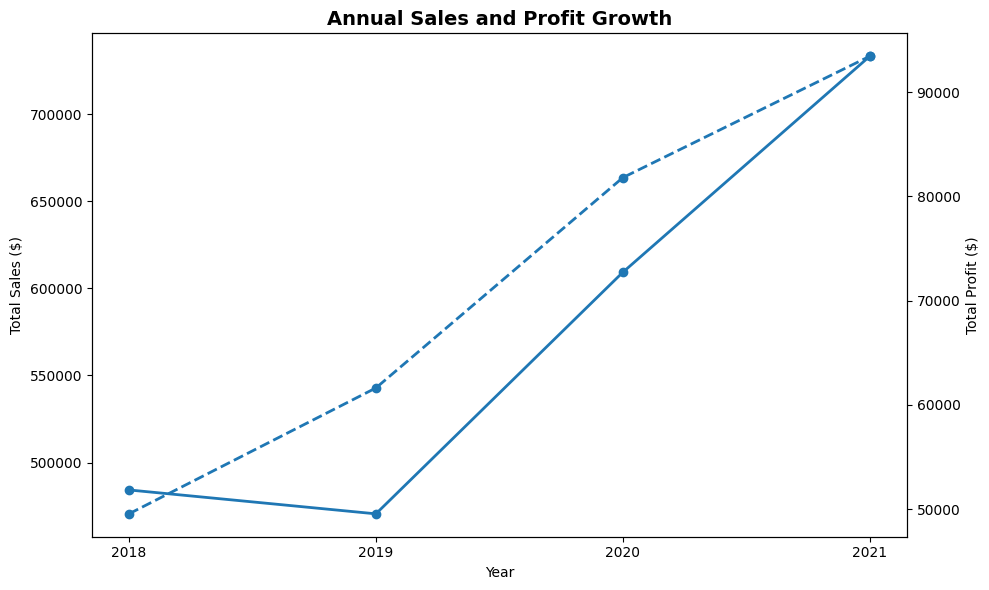

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    annual_performance.index,
    annual_performance["Total_Sales"],
    marker="o",
    linewidth=2,
    label="Sales"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Sales ($)")
ax1.set_xticks(annual_performance.index)

ax2 = ax1.twinx()

ax2.plot(
    annual_performance.index,
    annual_performance["Total_Profit"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Profit"
)

ax2.set_ylabel("Total Profit ($)")

plt.title(
    "Annual Sales and Profit Growth",
    fontsize=14,
    fontweight="bold"
)

fig.tight_layout()
plt.show()

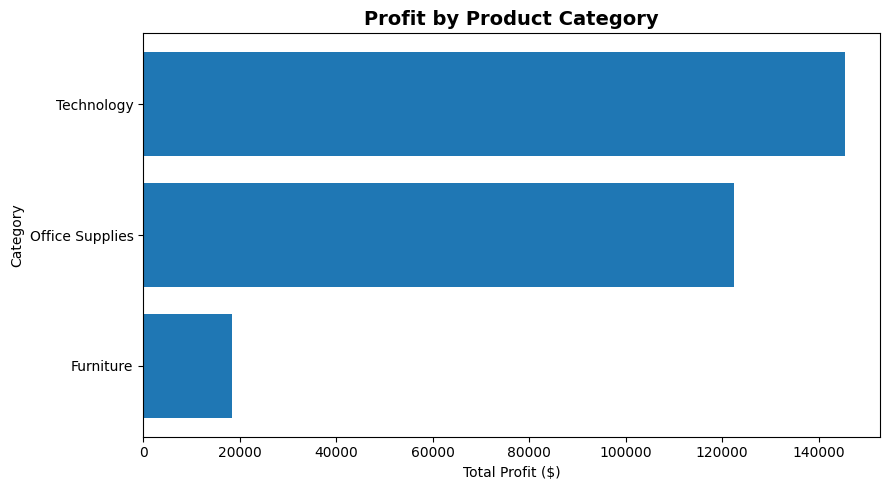

In [32]:
category_chart = (
    category_performance
    .sort_values("Total_Profit")
)

plt.figure(figsize=(9, 5))

plt.barh(
    category_chart.index,
    category_chart["Total_Profit"]
)

plt.title(
    "Profit by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Profit ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

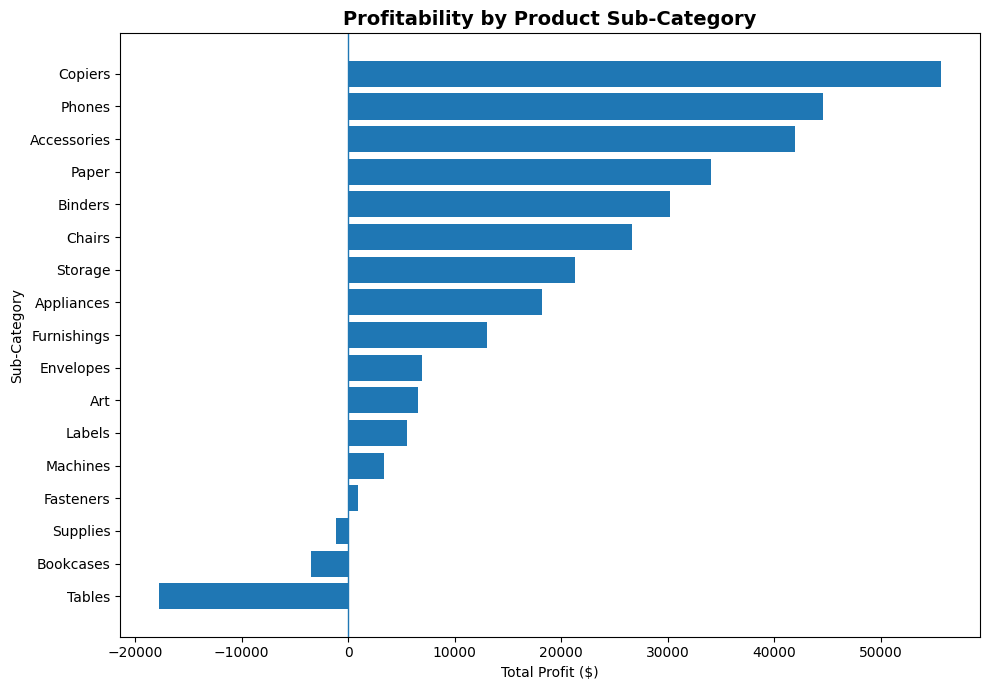

In [33]:
subcat_chart = (
    subcategory_performance
    .sort_values("Total_Profit")
)

plt.figure(figsize=(10, 7))

plt.barh(
    subcat_chart.index,
    subcat_chart["Total_Profit"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Profitability by Product Sub-Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

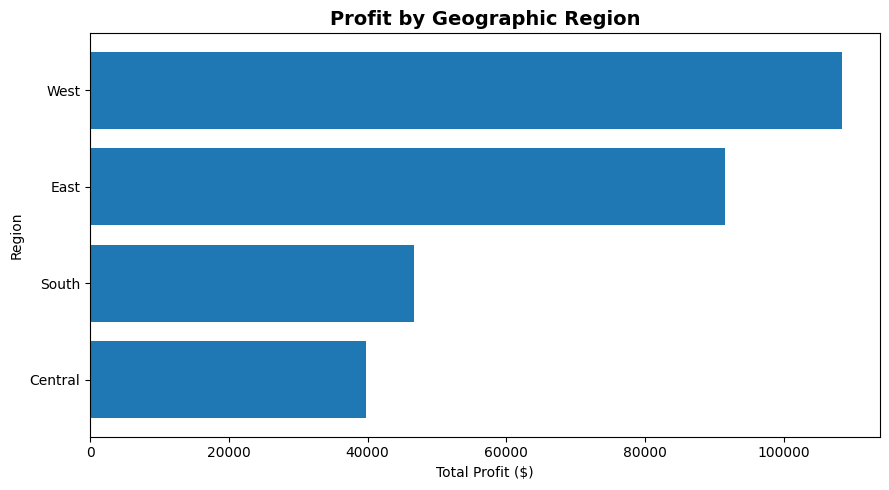

In [34]:
region_chart = (
    regional_performance
    .sort_values("Total_Profit")
)

plt.figure(figsize=(9, 5))

plt.barh(
    region_chart.index,
    region_chart["Total_Profit"]
)

plt.title(
    "Profit by Geographic Region",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Profit ($)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

## 10. Executive Findings and Recommendations

### Executive Summary

The exploratory analysis indicates that the retail business experienced substantial growth between 2018 and 2021, but profitability varies considerably across products, customers, geographic markets, and discount levels. Total sales increased 51.41% during the period, while total profit increased 88.60% and order volume increased 74.10%. Despite this overall improvement, several areas present opportunities for stronger margin management.

### Key Findings

1. **Revenue and Profit Growth:** Sales increased from approximately $484,248 in 2018 to $733,215 in 2021. Profit increased from approximately $49,544 to $93,439 over the same period.

2. **Seasonal Demand:** Sales generally strengthen during the later months of the year, with September through December accounting for several of the strongest monthly sales periods. This pattern should be considered when planning inventory, staffing, and promotional activity.

3. **Product Profitability:** Technology is the strongest overall category, generating approximately $145,455 in profit at a 17.40% margin. Furniture generated approximately $742,000 in sales but only $18,451 in profit, resulting in a 2.49% margin.

4. **Sub-Category Risk:** Tables generated approximately $206,966 in sales but produced a $17,725 loss. Bookcases and Supplies were also unprofitable. In contrast, Copiers generated approximately $55,618 in profit and achieved a 37.20% margin.

5. **Discount Risk:** Previous analysis demonstrated that transactions discounted 30% or more experienced substantially weaker profitability. Tables and Machines also exhibit relatively high average discount levels, indicating that discount strategy should be evaluated at the product level rather than through a uniform policy.

6. **Geographic Performance:** The West is the strongest region by total profit, while the Central region has the lowest regional profit margin. Texas generated approximately $170,188 in sales but lost approximately $25,729, producing a -15.12% margin while averaging approximately 37% in discounts.

7. **Customer Economics:** The Consumer segment generates the greatest sales and total profit but has the lowest segment profit margin. Customer-level sales and profit have a moderate positive correlation of approximately 0.51, demonstrating that high revenue does not necessarily indicate high customer profitability.

### Management Recommendations

Management should implement product- and market-specific discount controls rather than applying broad promotional policies. Particular attention should be directed toward Tables, Bookcases, Machines, Texas, and other markets demonstrating weak profitability.

The company should protect and expand high-performing product areas such as Copiers, Phones, Accessories, and other profitable Technology and Office Supplies products while investigating the pricing, shipping, discounting, and cost structures affecting Furniture.

Seasonal demand patterns should be incorporated into inventory forecasting, staffing, and promotional planning. Management should also evaluate customers using both revenue and profitability metrics to prevent high-sales but loss-making relationships from being incorrectly classified as high-value accounts.

Overall, the analysis demonstrates that continued revenue growth should be accompanied by stronger margin management. A data-driven approach to pricing, discounting, product strategy, customer management, and geographic performance could improve profitability without requiring equivalent increases in sales volume.

## 11. Conclusion

This exploratory data analysis transformed cleaned transactional data into actionable business intelligence by examining historical growth, seasonality, product performance, discount behavior, customer economics, and geographic profitability.

The analysis identified several opportunities for management intervention, particularly in discount strategy, Furniture profitability, loss-making states, and customer-level margin management.

The findings from this notebook provide the analytical foundation for subsequent SQL analysis and the development of an executive Power BI dashboard.